Sports centroid shape: (122, 301)
Sports max similarity shape: (122, 301)
Index(['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'POST_ID', 'TIMESTAMP',
       'LINK_SENTIMENT', 'PROPERTIES'],
      dtype='object')
Index(['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'POST_ID', 'TIMESTAMP',
       'LINK_SENTIMENT', 'PROPERTIES'],
      dtype='object')
Sports title posts date range:
2013-12-31 21:59:32
2017-04-30 16:15:30

Sports body posts date range:
2013-12-31 17:37:55
2017-04-30 15:08:45

LINK_SENTIMENT counts in title posts:
LINK_SENTIMENT
 1    11143
-1      950
Name: count, dtype: int64

LINK_SENTIMENT counts in body posts:
LINK_SENTIMENT
 1    10310
-1      313
Name: count, dtype: int64
LINK_SENTIMENT trends for subreddits: ['nba', 'nfl', 'hockey', 'fantasyfootball', 'cfb', 'maddenultimateteam', 'baseball', 'golf', 'patriots', 'collegebasketball', 'seahawks', 'minnesotavikings', 'madden', 'greenbaypackers', 'warriors', 'eagles', 'denverbroncos', 'torontobluejays', '49ers', 'lakers', 'browns',

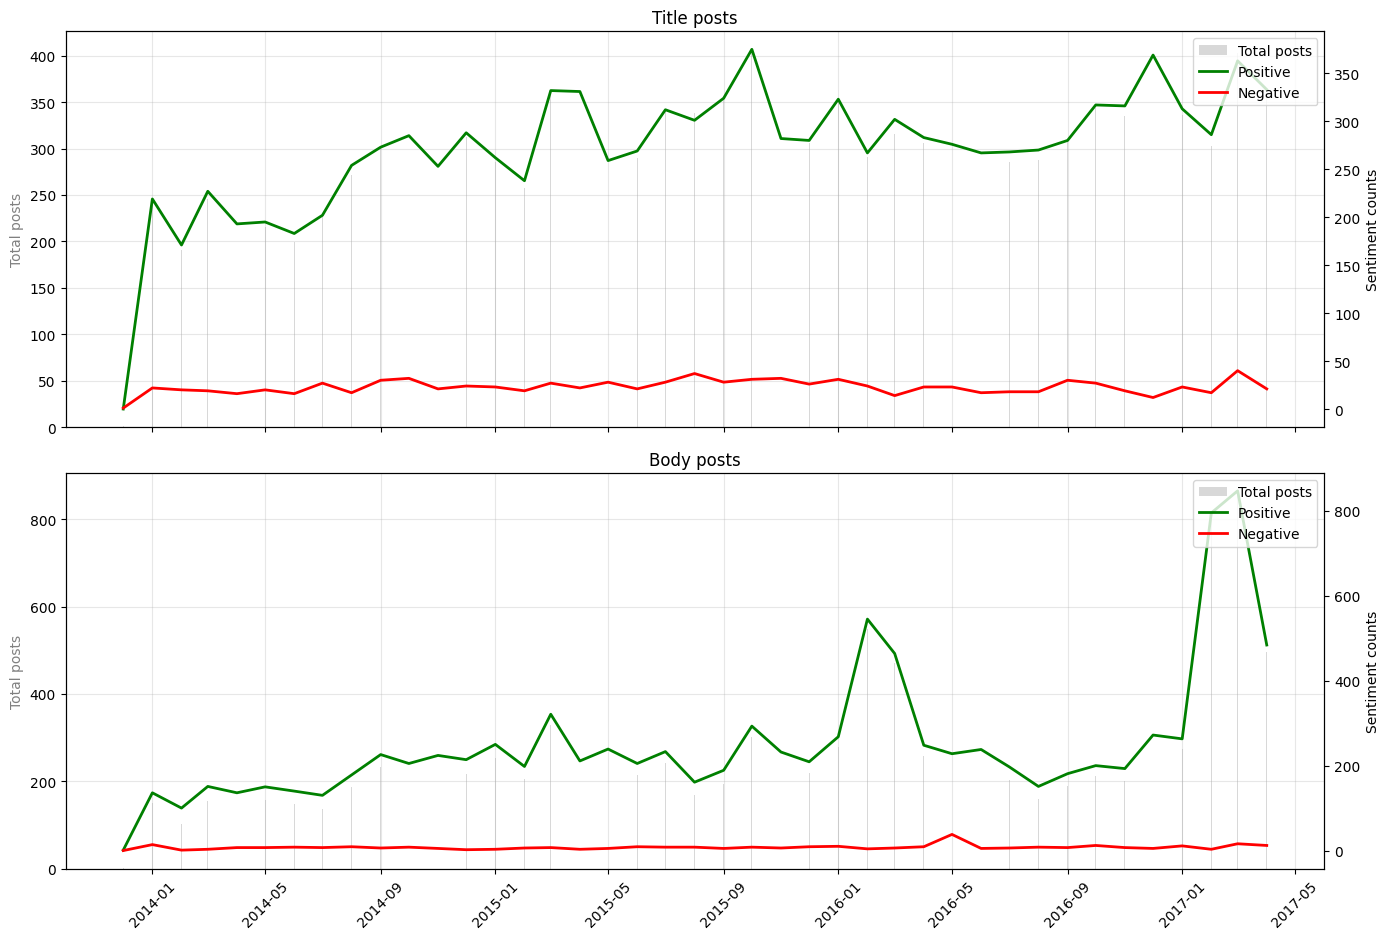

In [20]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from src.data import load_data

df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl, df_holidays = load_data()

THEMES = {
    'sports': [
        'nba', 'nfl', 'hockey', 'fantasyfootball', 'cfb', 'maddenultimateteam', 'baseball', 'golf', 'patriots', 'collegebasketball', 'seahawks', 'minnesotavikings', 'madden', 'greenbaypackers', 'warriors', 'eagles', 'denverbroncos', 'torontobluejays', '49ers', 'lakers', 'browns', 'oaklandraiders'
    ]
}

# Dictionary to hold merged dataframes
merged_dfs = {}

# Merge with the neighbors found (centroid)
for theme_name, initial_subs in THEMES.items():
    neighbors_centroid_path = f'../data/{theme_name}_centroid_neighbors.csv'

    if os.path.exists(neighbors_centroid_path):
        neighbors_df = pd.read_csv(neighbors_centroid_path)

        # Put all names in a list to filter duplicates
        merged_list = list(set(initial_subs + neighbors_df['SUBREDDIT'].tolist()))

        # Get the corresponding embeddings
        merged_df = df_subreddits[df_subreddits['SUBREDDIT'].isin(merged_list)].copy()

        # Save in dictionary for later use
        merged_dfs[f'{theme_name}_centroid'] = merged_df
    else:
        print(f'File not found :( ')

    # Do the same for max similarity neighbors

    neighbors_maxsim_path = f'../data/{theme_name}_max_similarity_neighbors.csv'

    if os.path.exists(neighbors_maxsim_path):
        neighbors_df = pd.read_csv(neighbors_maxsim_path)

        # Put all names in a list to filter duplicates
        merged_list = list(set(initial_subs + neighbors_df['SUBREDDIT'].tolist()))

        # Get the corresponding embeddings
        merged_df = df_subreddits[df_subreddits['SUBREDDIT'].isin(merged_list)].copy()

        # Save in dictionary for later use
        merged_dfs[f'{theme_name}_maxsim'] = merged_df
    else:
        print(f'File not found :( ')

# Dataframes
sports_centroid_df = merged_dfs.get('sports_centroid')
# politics_centroid_df = merged_dfs.get('politics_centroid')
# gaming_centroid_df = merged_dfs.get('gaming_centroid')
sports_maxsim_df = merged_dfs.get('sports_maxsim')
# politics_maxsim_df = merged_dfs.get('politics_maxsim')
# gaming_maxsim_df = merged_dfs.get('gaming_maxsim')

print("Sports centroid shape:", sports_centroid_df.shape if sports_centroid_df is not None else "Not found")
print("Sports max similarity shape:", sports_maxsim_df.shape if sports_maxsim_df is not None else "Not found")

features = [
    "Number of characters",
    "Number of characters without counting white space",
    "Fraction of alphabetical characters",
    "Fraction of digits",
    "Fraction of uppercase characters",
    "Fraction of white spaces",
    "Fraction of special characters (e.g., comma, exclamation mark, etc.)",
    "Number of words",
    "Number of unique words",
    "Number of long words (at least 6 characters)",
    "Average word length",
    "Number of unique stopwords",
    "Fraction of stopwords",
    "Number of sentences",
    "Number of long sentences (at least 10 words)",
    "Average number of characters per sentence",
    "Average number of words per sentence",
    "Automated readability index",
    "Positive sentiment (VADER)",
    "Negative sentiment (VADER)",
    "Compound sentiment (VADER)",
    "LIWC_Funct",
    "LIWC_Pronoun",
    "LIWC_Ppron",
    "LIWC_I",
    "LIWC_We",
    "LIWC_You",
    "LIWC_SheHe",
    "LIWC_They",
    "LIWC_Ipron",
    "LIWC_Article",
    "LIWC_Verbs",
    "LIWC_AuxVb",
    "LIWC_Past",
    "LIWC_Present",
    "LIWC_Future",
    "LIWC_Adverbs",
    "LIWC_Prep",
    "LIWC_Conj",
    "LIWC_Negate",
    "LIWC_Quant",
    "LIWC_Numbers",
    "LIWC_Swear",
    "LIWC_Social",
    "LIWC_Family",
    "LIWC_Friends",
    "LIWC_Humans",
    "LIWC_Affect",
    "LIWC_Posemo",
    "LIWC_Negemo",
    "LIWC_Anx",
    "LIWC_Anger",
    "LIWC_Sad",
    "LIWC_CogMech",
    "LIWC_Insight",
    "LIWC_Cause",
    "LIWC_Discrep",
    "LIWC_Tentat",
    "LIWC_Certain",
    "LIWC_Inhib",
    "LIWC_Incl",
    "LIWC_Excl",
    "LIWC_Percept",
    "LIWC_See",
    "LIWC_Hear",
    "LIWC_Feel",
    "LIWC_Bio",
    "LIWC_Body",
    "LIWC_Health",
    "LIWC_Sexual",
    "LIWC_Ingest",
    "LIWC_Relativ",
    "LIWC_Motion",
    "LIWC_Space",
    "LIWC_Time",
    "LIWC_Work",
    "LIWC_Achiev",
    "LIWC_Leisure",
    "LIWC_Home",
    "LIWC_Money",
    "LIWC_Relig",
    "LIWC_Death",
    "LIWC_Assent",
    "LIWC_Dissent",
    "LIWC_Nonflu",
    "LIWC_Filler"
]

def get_dataframe_features(tf, tf2, subreddits_list):
    df_title_prop = tf[
        (
            tf["SOURCE_SUBREDDIT"].isin(subreddits_list) |
            tf["TARGET_SUBREDDIT"].isin(subreddits_list)
        )
    ]

    df_body_prop = tf2[
        (
            tf2["SOURCE_SUBREDDIT"].isin(subreddits_list) |
            tf2["TARGET_SUBREDDIT"].isin(subreddits_list)
        )
    ]
    raw_rows =[]
    for f in features[18:]:
        raw_rows.append((
            f,
            round(df_title_prop[f].mean(), 5),
            round(df_title_prop[f].max(), 2),
            round(df_title_prop[f].sum(), 2),
            round(df_title_prop[f].std(), 5),
            round(df_body_prop[f].mean(), 5),
            round(df_body_prop[f].max(), 2),
            round(df_body_prop[f].sum(), 2),
            round(df_body_prop[f].std(), 5),
        ))
    columns=["Feature", "Mean_Title", "Max_Title", "Sum_Title", "Std_Title", "Mean_Body", "Max_Body", "Sum_Body", "Std_Body"]
    df_features = pd.DataFrame(raw_rows, columns=columns)
    df_features_sentiment = df_features.loc[:2]
    df_features_liwc = df_features.loc[3:]
    return df_features_sentiment, df_features_liwc


def plot_subreddits_features_trend(tf, subreddits_list, start_time, end_time, features_list, period):

    period_map = { "D": "DAY", "W": "WEEK", "M": "MONTH", "Q": "QUARTER", "Y": "YEAR" }

    start_time = pd.Timestamp(start_time)
    end_time   = pd.Timestamp(end_time)
    
    # apply filters
    df = tf[
        (
            tf["SOURCE_SUBREDDIT"].isin(subreddits_list) |
            tf["TARGET_SUBREDDIT"].isin(subreddits_list)
        )
        & (tf["TIMESTAMP"] >= start_time)
        & (tf["TIMESTAMP"] <= end_time)
    ]
    df = df.assign(**{period_map[period]: df["TIMESTAMP"].dt.to_period(period)})


    period_stats = (
        df.groupby(period_map[period])[features_list]
        .sum()
        .assign(Count=df.groupby(period_map[period]).size())
    )
    period_stats.index = period_stats.index.to_timestamp()

    fig, ax1 = plt.subplots(figsize=(16,6))

    # Bar plot for post count
    ax1.bar(period_stats.index, period_stats["Count"], color="gray", alpha=0.3)
    ax1.set_ylabel("Post Count", color="gray")
    ax1.set_xlabel(period_map[period])
    ax1.tick_params(axis="y")

    # Line plot for each sentiment on the second axis
    ax2 = ax1.twinx()
    for f in features_list:
        ax2.plot(period_stats.index, period_stats[f], label=f, linewidth=2)
    ax2.set_ylabel("Sum of Feature Values")
    ax2.tick_params(axis="y")

    # Title and legend
    plt.title(f"Sentiment {features_list}\n{period_map[period]} Trends ({start_time.date()} – {end_time.date()})\nwithin {subreddits_list}")
    fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes, title="Features")
    fig.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------------------------------------------------------------------------

print(df_title.columns)
print(df_body.columns)

sports_subreddits = THEMES['sports']

# Filter posts for sports subreddits
df_title_sports = df_title[
    df_title["SOURCE_SUBREDDIT"].isin(sports_subreddits) |
    df_title["TARGET_SUBREDDIT"].isin(sports_subreddits)
]

df_body_sports = df_body[
    df_body["SOURCE_SUBREDDIT"].isin(sports_subreddits) |
    df_body["TARGET_SUBREDDIT"].isin(sports_subreddits)
]

print("Sports title posts date range:")
print(df_title_sports["TIMESTAMP"].min())
print(df_title_sports["TIMESTAMP"].max())

print("\nSports body posts date range:")
print(df_body_sports["TIMESTAMP"].min())
print(df_body_sports["TIMESTAMP"].max())

# Simple EDA using LINK_SENTIMENT
print("\nLINK_SENTIMENT counts in title posts:")
print(df_title_sports["LINK_SENTIMENT"].value_counts())

print("\nLINK_SENTIMENT counts in body posts:")
print(df_body_sports["LINK_SENTIMENT"].value_counts())

# ----------------------------------------------------------------------------------------------------------------------------------------------------

# Plot LINK_SENTIMENT trends over time for title and body posts side by side
def plot_title_body_sentiment_trends(df_title, df_body, subreddits_list, start_time, end_time, period="M"):
    
    # df_title: DataFrame with title posts
    # df_body: DataFrame with body posts
    # subreddits_list: list of subreddits to include
    # start_time, end_time: str or pd.Timestamp
    # period: str, aggregation period ('D', 'W', 'M', 'Q', 'Y')
    
    start_time = pd.Timestamp(start_time)
    end_time = pd.Timestamp(end_time)
    
    def get_sentiment_counts(df):
        df_filtered = df[
            (df["SOURCE_SUBREDDIT"].isin(subreddits_list) |
             df["TARGET_SUBREDDIT"].isin(subreddits_list)) &
            (df["TIMESTAMP"] >= start_time) &
            (df["TIMESTAMP"] <= end_time)
        ]
        df_filtered = df_filtered.assign(period=df_filtered["TIMESTAMP"].dt.to_period(period))
        counts = df_filtered.groupby(["period", "LINK_SENTIMENT"]).size().unstack(fill_value=0)
        counts.index = counts.index.to_timestamp()
        counts["Total"] = counts.sum(axis=1)
        return counts
    
    title_counts = get_sentiment_counts(df_title)
    body_counts = get_sentiment_counts(df_body)
    
    # Create side-by-side plots
    fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)  # stacked vertically

    for ax, counts, label in zip(axs, [title_counts, body_counts], ["Title posts", "Body posts"]):
        # Bar for total posts on left y-axis
        ax.bar(counts.index, counts["Total"], color="gray", alpha=0.3, label="Total posts")
        ax.set_ylabel("Total posts", color="gray")
        
        # Create a second y-axis for sentiment lines
        ax2 = ax.twinx()
        if 1 in counts.columns:
            ax2.plot(counts.index, counts[1], color="green", lw=2, label="Positive")
        if -1 in counts.columns:
            ax2.plot(counts.index, counts[-1], color="red", lw=2, label="Negative")
        ax2.set_ylabel("Sentiment counts")
        
        # Titles, grid, legend
        ax.set_title(label)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", rotation=45)
        
        # Combine legends
        lines, labels = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc="upper right")

    print(f"LINK_SENTIMENT trends for subreddits: {subreddits_list}")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ------------------------------------------------------------------------------------------------------------------------------------------------

# SPORTS
sports_subreddits = THEMES['sports']

plot_title_body_sentiment_trends(
    df_title,
    df_body,
    sports_subreddits,
    start_time="2013-12-31",
    end_time="2017-04-30",
    period="M"
)


Index(['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'POST_ID', 'TIMESTAMP',
       'LINK_SENTIMENT', 'PROPERTIES'],
      dtype='object')
Index(['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'POST_ID', 'TIMESTAMP',
       'LINK_SENTIMENT', 'PROPERTIES'],
      dtype='object')
Sports title posts date range:
2013-12-31 21:59:32
2017-04-30 16:15:30

Sports body posts date range:
2013-12-31 17:37:55
2017-04-30 15:08:45

LINK_SENTIMENT counts in title posts:
LINK_SENTIMENT
 1    11143
-1      950
Name: count, dtype: int64

LINK_SENTIMENT counts in body posts:
LINK_SENTIMENT
 1    10310
-1      313
Name: count, dtype: int64

Missing values in title posts:
SOURCE_SUBREDDIT    0
TARGET_SUBREDDIT    0
POST_ID             0
TIMESTAMP           0
LINK_SENTIMENT      0
PROPERTIES          0
dtype: int64

Missing values in body posts:
SOURCE_SUBREDDIT    0
TARGET_SUBREDDIT    0
POST_ID             0
TIMESTAMP           0
LINK_SENTIMENT      0
PROPERTIES          0
dtype: int64


C:\Users\Arnau\AppData\Local\Temp\ipykernel_21516\348177162.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_title_sports['title_length'] = df_title_sports['PROPERTIES'].apply(lambda x: len(str(x)))
C:\Users\Arnau\AppData\Local\Temp\ipykernel_21516\348177162.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_body_sports['body_length'] = df_body_sports['PROPERTIES'].apply(lambda x: len(str(x)))


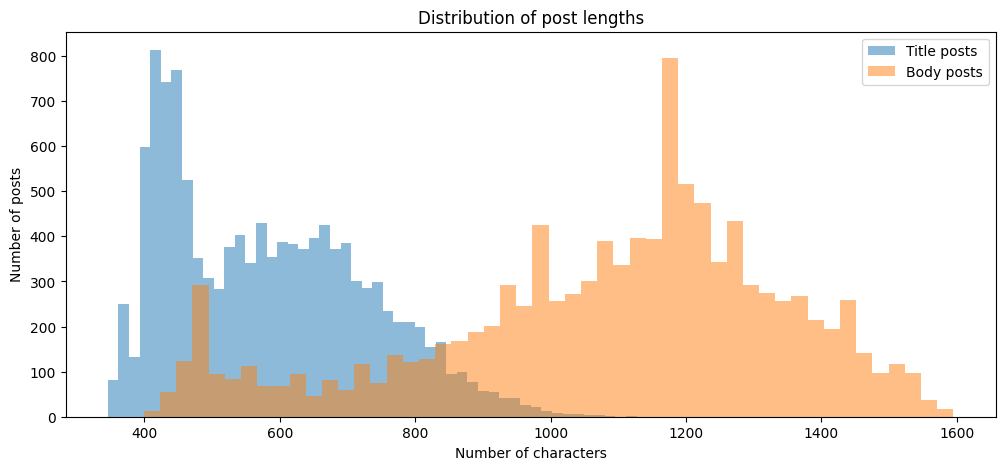

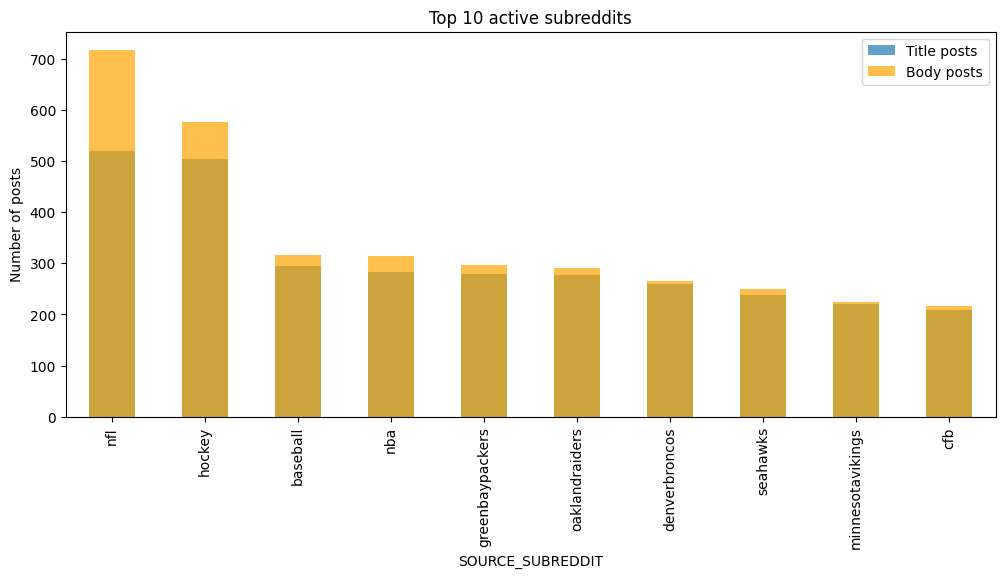

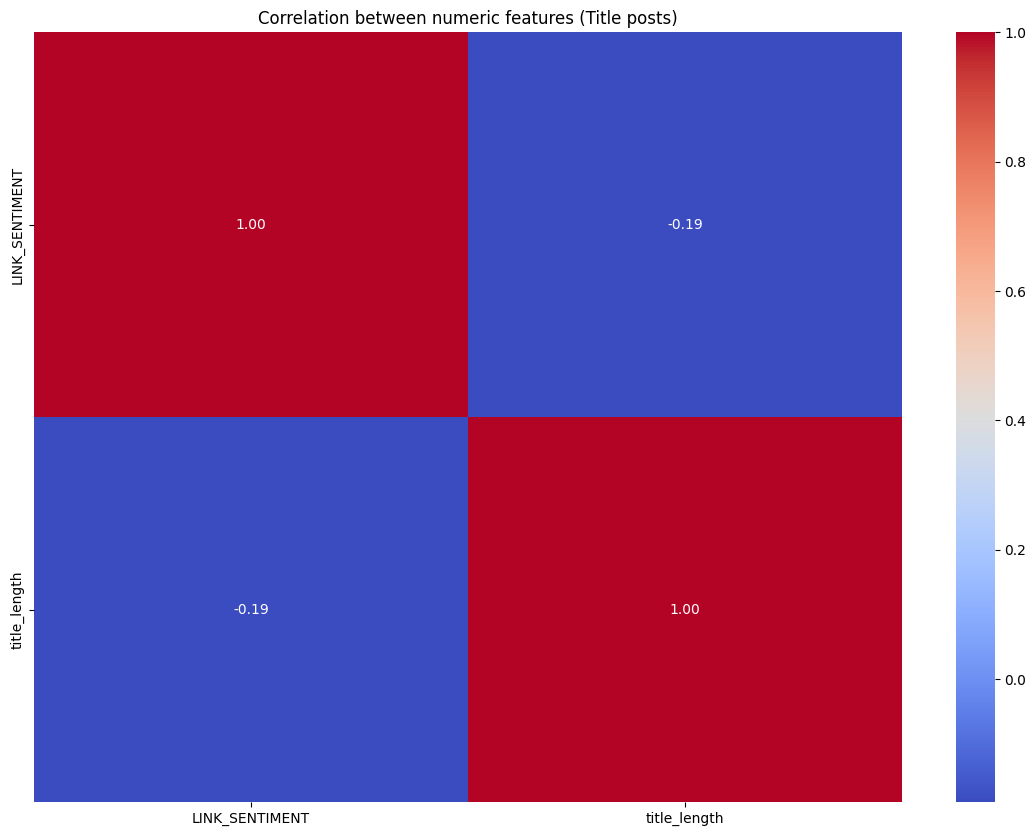

C:\Users\Arnau\AppData\Local\Temp\ipykernel_21516\348177162.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_title_sports['month'] = df_title_sports['TIMESTAMP'].dt.to_period('M')
C:\Users\Arnau\AppData\Local\Temp\ipykernel_21516\348177162.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_body_sports['month'] = df_body_sports['TIMESTAMP'].dt.to_period('M')


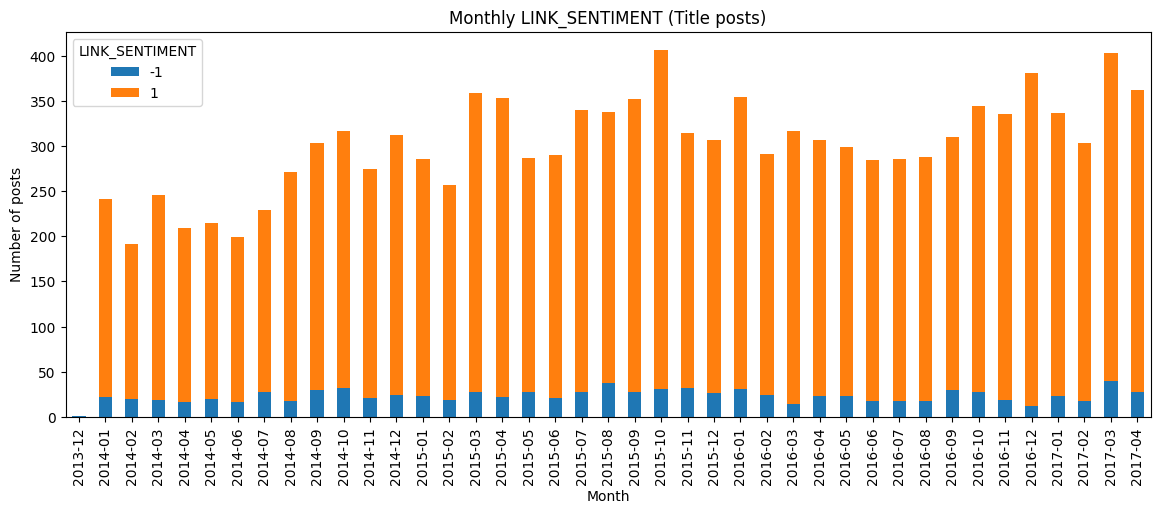

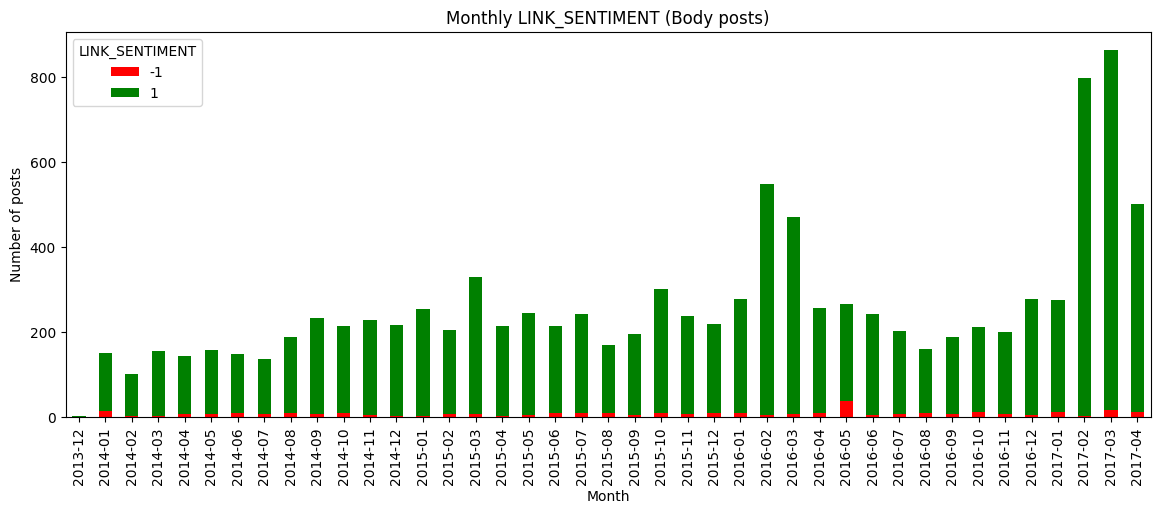

In [ ]:
# ------------------------------------------------------------------------
# Existing EDA
print(df_title.columns)
print(df_body.columns)

sports_subreddits = THEMES['sports']

# Filter posts for sports subreddits
df_title_sports = df_title[
    df_title["SOURCE_SUBREDDIT"].isin(sports_subreddits) |
    df_title["TARGET_SUBREDDIT"].isin(sports_subreddits)
]

df_body_sports = df_body[
    df_body["SOURCE_SUBREDDIT"].isin(sports_subreddits) |
    df_body["TARGET_SUBREDDIT"].isin(sports_subreddits)
]

print("Sports title posts date range:")
print(df_title_sports["TIMESTAMP"].min())
print(df_title_sports["TIMESTAMP"].max())

print("\nSports body posts date range:")
print(df_body_sports["TIMESTAMP"].min())
print(df_body_sports["TIMESTAMP"].max())

# Simple EDA using LINK_SENTIMENT
print("\nLINK_SENTIMENT counts in title posts:")
print(df_title_sports["LINK_SENTIMENT"].value_counts())

print("\nLINK_SENTIMENT counts in body posts:")
print(df_body_sports["LINK_SENTIMENT"].value_counts())


############################################# EDA ##############################################

# Check for missing values
print("\nMissing values in title posts:")
print(df_title_sports.isnull().sum())
print("\nMissing values in body posts:")
print(df_body_sports.isnull().sum())

# (Distribution of post lengths)
df_title_sports['title_length'] = df_title_sports['PROPERTIES'].apply(lambda x: len(str(x)))
df_body_sports['body_length'] = df_body_sports['PROPERTIES'].apply(lambda x: len(str(x)))

plt.figure(figsize=(12,5))
plt.hist(df_title_sports['title_length'], bins=50, alpha=0.5, label='Title posts')
plt.hist(df_body_sports['body_length'], bins=50, alpha=0.5, label='Body posts')
plt.xlabel('Number of characters')
plt.ylabel('Number of posts')
plt.title('Distribution of post lengths')
plt.legend()
plt.show()

# Top active subreddits
top_title_subs = df_title_sports['SOURCE_SUBREDDIT'].value_counts().head(10)
top_body_subs = df_body_sports['SOURCE_SUBREDDIT'].value_counts().head(10)

plt.figure(figsize=(12,5))
top_title_subs.plot(kind='bar', alpha=0.7, label='Title posts')
top_body_subs.plot(kind='bar', alpha=0.7, label='Body posts', color='orange')
plt.ylabel('Number of posts')
plt.title('Top 10 active subreddits')
plt.legend()
plt.show()

# Correlation heatmap for numeric features
numeric_cols = df_title_sports.select_dtypes(include='number').columns
if len(numeric_cols) > 1:
    import seaborn as sns
    plt.figure(figsize=(14,10))
    sns.heatmap(df_title_sports[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
    plt.title('Correlation between numeric features (Title posts)')
    plt.show()

# LINK_SENTIMENT histogram over time (monthly)
df_title_sports['month'] = df_title_sports['TIMESTAMP'].dt.to_period('M')
df_body_sports['month'] = df_body_sports['TIMESTAMP'].dt.to_period('M')

title_sentiment_month = df_title_sports.groupby(['month', 'LINK_SENTIMENT']).size().unstack(fill_value=0)
body_sentiment_month = df_body_sports.groupby(['month', 'LINK_SENTIMENT']).size().unstack(fill_value=0)

title_sentiment_month.plot(kind='bar', stacked=True, figsize=(14,5), title='Monthly LINK_SENTIMENT (Title posts)')
plt.xlabel('Month')
plt.ylabel('Number of posts')
plt.show()

body_sentiment_month.plot(kind='bar', stacked=True, figsize=(14,5), title='Monthly LINK_SENTIMENT (Body posts)', color=['red','green'])
plt.xlabel('Month')
plt.ylabel('Number of posts')
plt.show()
